# CLNSIG – Dataset Anotat
Aquest notebook entrena els sis models de classificació per a la 
predicció de significança clínica sobre el dataset 
anotat, que  inclou les anotacions funcionals VEP.

## Imports

In [29]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.sparse
import shap

from sklearn.compose import ColumnTransformer
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    classification_report, f1_score, confusion_matrix
)

warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
    module=r"sklearn\.utils\.extmath"
)

## Càrrega de dades

In [30]:
df = pd.read_csv("../data/raw/clinvar_clnsig_annotated.csv")
print(df.shape)
print(df.columns.tolist())
print(df["CLNSIG"].value_counts(dropna=False).head(30))

(60480, 47)
['CHROM', 'POS', 'REF', 'ALT', 'AF_ESP', 'AF_EXAC', 'AF_TGP', 'CLNDISDB', 'CLNDISDBINCL', 'CLNDN', 'CLNDNINCL', 'CLNHGVS', 'CLNSIG', 'CLNSIGINCL', 'CLNVC', 'CLNVI', 'MC', 'ORIGIN', 'SSR', 'CLASS', 'Allele', 'Consequence', 'IMPACT', 'SYMBOL', 'Feature_type', 'Feature', 'BIOTYPE', 'EXON', 'INTRON', 'cDNA_position', 'CDS_position', 'Protein_position', 'Amino_acids', 'Codons', 'DISTANCE', 'STRAND', 'BAM_EDIT', 'SIFT', 'PolyPhen', 'MOTIF_NAME', 'MOTIF_POS', 'HIGH_INF_POS', 'MOTIF_SCORE_CHANGE', 'LoFtool', 'CADD_PHRED', 'CADD_RAW', 'BLOSUM62']
CLNSIG
Uncertain_significance                                       20358
Likely_benign                                                13549
Benign                                                        8272
Pathogenic                                                    7073
Benign/Likely_benign                                          4824
Likely_pathogenic                                             2432
Conflicting_interpretations_of_path

## Distribucio de la variable objectiu (CLNSIG)

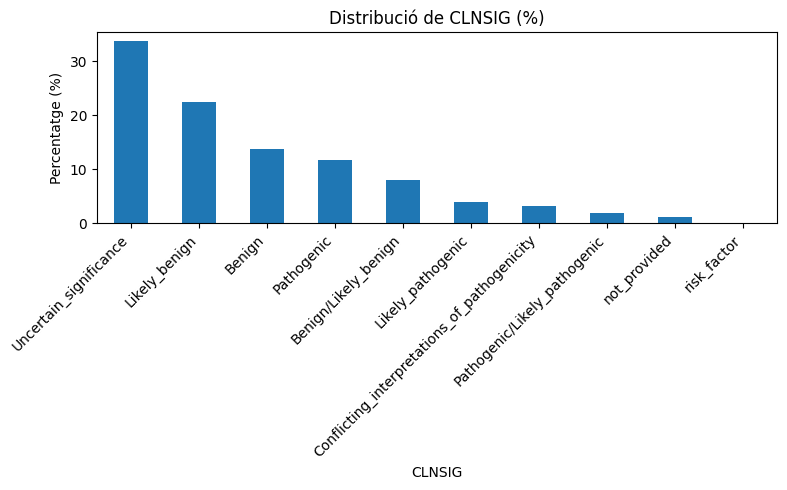

In [31]:
# Visualitzar la distribució de les classes a CLNSIG
counts = df["CLNSIG"].value_counts(dropna=False)
percent = (counts / counts.sum()) * 100
top_percent = percent.head(10)

plt.figure(figsize=(8,5))
top_percent.plot(kind="bar")

plt.title("Distribució de CLNSIG (%)")
plt.ylabel("Percentatge (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Creació Classes i Partició de dades  

In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Valors que pertanyen a cada classe
benign_values = [
    "Benign", "Likely_benign", "Benign/Likely_benign",
    "Benign,_risk_factor", "Benign,_other", "Benign,_association",
    "Benign/Likely_benign,_risk_factor", "Benign/Likely_benign,_other",
    "Likely_benign,_risk_factor", "Likely_benign,_association"
]
vus_values = [
    "Uncertain_significance"
]
pathogenic_values = [
    "Pathogenic", "Likely_pathogenic", "Pathogenic/Likely_pathogenic",
    "Pathogenic,_risk_factor", "Pathogenic/Likely_pathogenic,_risk_factor",
    "Pathogenic,_association"
]

clnsig_map = (
    {v: 0 for v in benign_values} |
    {v: 1 for v in vus_values}    |
    {v: 2 for v in pathogenic_values}
)

# Filtrar i crear target (descartem Conflicting, not_provided, etc.)
df_multi = df[df["CLNSIG"].isin(clnsig_map.keys())].copy()
df_multi["CLNSIG_target"] = df_multi["CLNSIG"].map(clnsig_map)

# Comprovació distribució
print(df_multi["CLNSIG_target"].value_counts())
print(df_multi["CLNSIG_target"].value_counts(normalize=True).round(3))

# Columnes a eliminar: target, CLASS antiga, i les que revelarien el resultat
cols_to_drop = ["CLNSIG", "CLNSIG_target", "CLASS"]

for col in ["CLNSIGCONF", "CLNREVSTAT"]:
    if col in df_multi.columns:
        cols_to_drop.append(col)

X = df_multi.drop(columns=cols_to_drop)
y = df_multi["CLNSIG_target"]

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.10,
    random_state=42,
    stratify=y
)

print(f"\nX_train_val: {X_train_val.shape}")
print(f"X_test:      {X_test.shape}")

CLNSIG_target
0    26692
1    20358
2    10641
Name: count, dtype: int64
CLNSIG_target
0    0.463
1    0.353
2    0.184
Name: proportion, dtype: float64

X_train_val: (51921, 45)
X_test:      (5770, 45)


## Distribucio de la variable objectiu (CLNSIG) després de la creació de classes

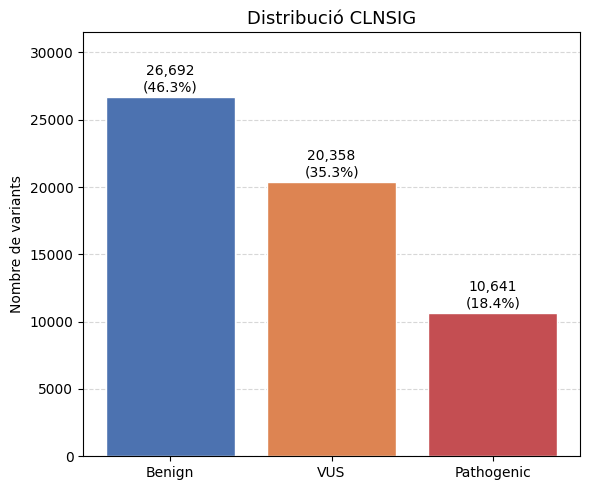

In [33]:
# Distribució de les 3 classes CLNSIG (després del filtratge)
CLASS_LABELS = {0: "Benign", 1: "VUS", 2: "Pathogenic"}
COLORS = ["#4C72B0", "#DD8452", "#C44E52"]

counts = df_multi["CLNSIG_target"].value_counts().sort_index()
labels = [CLASS_LABELS[i] for i in counts.index]
pcts   = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(6, 5))

bars = ax.bar(labels, counts.values, color=COLORS, edgecolor="white")
for bar, n, pct in zip(bars, counts.values, pcts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 200,
            f"{n:,}\n({pct:.1f}%)",
            ha="center", va="bottom", fontsize=10)
ax.set_title(f"Distribució CLNSIG", fontsize=13)
ax.set_ylabel("Nombre de variants")
ax.set_ylim(0, counts.max() * 1.18)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Preprocessat 

In [ ]:
# Eliminar columnes amb alt percentatge de valors faltants 
cols_high_missing = [
    'MOTIF_SCORE_CHANGE', 'HIGH_INF_POS', 'MOTIF_POS', 'MOTIF_NAME',
    'DISTANCE', 'SSR', 'CLNSIGINCL', 'CLNDISDBINCL', 'CLNDNINCL'
]
X_train_val = X_train_val.drop(columns=cols_high_missing, errors="ignore")
X_test      = X_test.drop(columns=cols_high_missing, errors="ignore")

cols_all_missing = X_train_val.columns[X_train_val.isnull().mean() == 1.0].tolist()
if cols_all_missing:
    X_train_val = X_train_val.drop(columns=cols_all_missing)
    X_test      = X_test.drop(columns=cols_all_missing, errors="ignore")

num_cols = X_train_val.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train_val.select_dtypes(exclude=np.number).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", min_frequency=20)),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols),
])

print("X_train_val shape:", X_train_val.shape)
print("X_test shape:", X_test.shape)

X_train_val shape: (51921, 36)
X_test shape: (5770, 36)


# Entrenament dels models

In [ ]:
# Noms de les classes per als plots
CLASS_NAMES = ["Benign", "VUS", "Pathogenic"]
 
# Funció auxiliar per pintar la confusion matrix 
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.tight_layout()
    plt.show()
 
 

## LinearSVC

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Millors paràmetres: {'model__C': 0.1, 'model__class_weight': 'balanced'}
Millor CV F1 macro:  0.8594

Classification report al test:
              precision    recall  f1-score   support

      Benign       0.90      0.90      0.90      2670
         VUS       0.80      0.85      0.82      2036
  Pathogenic       0.92      0.84      0.88      1064

    accuracy                           0.87      5770
   macro avg       0.88      0.86      0.87      5770
weighted avg       0.87      0.87      0.87      5770


Test F1 macro: 0.8676
Confusion matrix:
[[2396  267    7]
 [ 245 1722   69]
 [  18  152  894]]


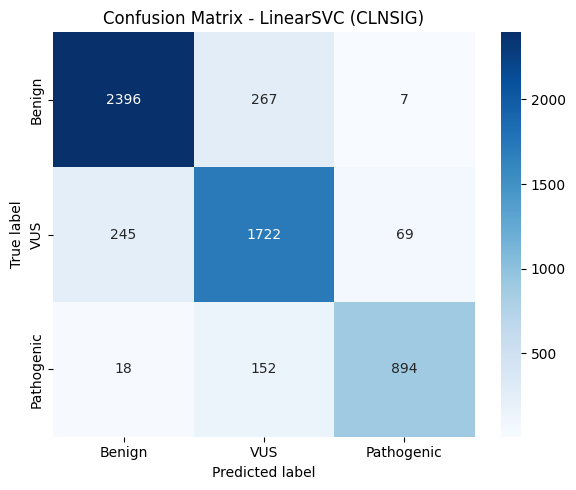

In [ ]:


# Model base
svc = LinearSVC(random_state=42, max_iter=2000)

# Pipeline preprocessament + model
pipeline_svc = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", svc)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cerca d'hiperparàmetres
param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1.0, 10.0],
    "model__class_weight": [None, "balanced"]
}

grid_svc = GridSearchCV(
    pipeline_svc,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    error_score="raise"
)

grid_svc.fit(X_train_val, y_train_val)

# Resultats de la validació creuada
print(f"Millors paràmetres: {grid_svc.best_params_}")
print(f"Millor CV F1 macro:  {grid_svc.best_score_:.4f}")

best_svc = grid_svc.best_estimator_
y_pred_svc = best_svc.predict(X_test)

print("\nClassification report al test:")
print(classification_report(y_test, y_pred_svc, target_names=CLASS_NAMES))
print(f"\nTest F1 macro: {f1_score(y_test, y_pred_svc, average='macro'):.4f}")
print(f"Confusion matrix:\n{confusion_matrix(y_test, y_pred_svc)}")

plot_confusion_matrix(
    confusion_matrix(y_test, y_pred_svc),
    "Confusion Matrix - LinearSVC (CLNSIG)"
)

## Logistic Regression L1

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Millors paràmetres: {'model__C': 10.0, 'model__class_weight': None}
Millor CV F1 macro:  0.8543

Classification report al test:
              precision    recall  f1-score   support

      Benign       0.95      0.85      0.90      2670
         VUS       0.78      0.89      0.83      2036
  Pathogenic       0.86      0.86      0.86      1064

    accuracy                           0.86      5770
   macro avg       0.86      0.87      0.86      5770
weighted avg       0.87      0.86      0.87      5770


Test F1 macro: 0.8622
Confusion matrix:
[[2260  374   36]
 [ 106 1814  116]
 [   3  145  916]]


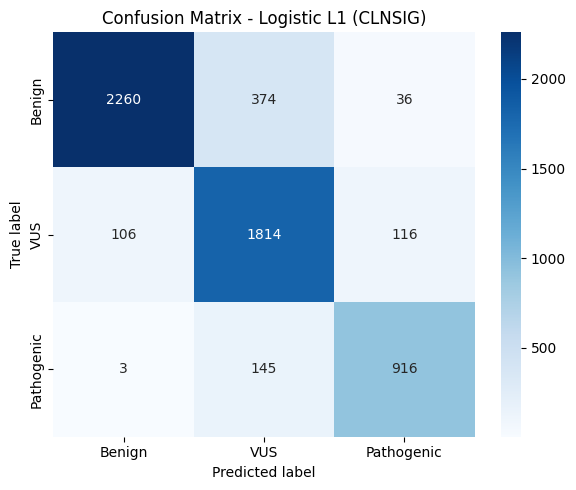

In [ ]:

# Model base
lr_l1 = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    max_iter=1000,
    random_state=42
)

# Pipeline preprocessament + model
pipeline_lr_l1 = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", lr_l1)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cerca d'hiperparàmetres
param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1.0, 10.0],
    "model__class_weight": [None, "balanced"]
}

grid_lr_l1 = GridSearchCV(
    pipeline_lr_l1,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    error_score="raise"
)

grid_lr_l1.fit(X_train_val, y_train_val)

# Resultats de la validació creuada
print(f"Millors paràmetres: {grid_lr_l1.best_params_}")
print(f"Millor CV F1 macro:  {grid_lr_l1.best_score_:.4f}")

best_lr_l1 = grid_lr_l1.best_estimator_
y_pred_lr_l1 = best_lr_l1.predict(X_test)

print("\nClassification report al test:")
print(classification_report(y_test, y_pred_lr_l1, target_names=CLASS_NAMES))
print(f"\nTest F1 macro: {f1_score(y_test, y_pred_lr_l1, average='macro'):.4f}")
print(f"Confusion matrix:\n{confusion_matrix(y_test, y_pred_lr_l1)}")

plot_confusion_matrix(
    confusion_matrix(y_test, y_pred_lr_l1),
    "Confusion Matrix - Logistic L1 (CLNSIG)"
)

## Logistic Regression L2

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Millors paràmetres: {'model__C': 0.1, 'model__class_weight': 'balanced'}
Millor CV F1 macro:  0.8622

Classification report al test:
              precision    recall  f1-score   support

      Benign       0.94      0.86      0.90      2670
         VUS       0.78      0.88      0.83      2036
  Pathogenic       0.89      0.86      0.87      1064

    accuracy                           0.87      5770
   macro avg       0.87      0.87      0.87      5770
weighted avg       0.88      0.87      0.87      5770


Test F1 macro: 0.8678
Confusion matrix:
[[2304  351   15]
 [ 146 1798   92]
 [  11  143  910]]


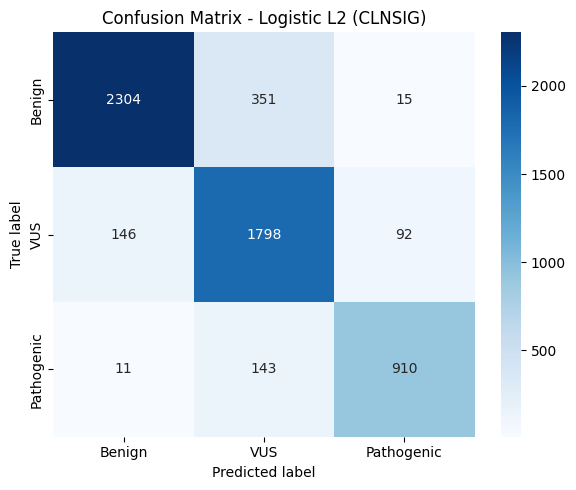

In [ ]:

# Model base
lr_l2 = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42)

# Pipeline preprocessament + model
pipeline_lr_l2 = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", lr_l2)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cerca d'hiperparàmetres
param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1.0, 10.0],
    "model__class_weight": [None, "balanced"]
}

grid_lr_l2 = GridSearchCV(
    pipeline_lr_l2,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    error_score="raise"
)

grid_lr_l2.fit(X_train_val, y_train_val)

# Resultats de la validació creuada
print(f"Millors paràmetres: {grid_lr_l2.best_params_}")
print(f"Millor CV F1 macro:  {grid_lr_l2.best_score_:.4f}")

best_lr_l2 = grid_lr_l2.best_estimator_
y_pred_lr_l2 = best_lr_l2.predict(X_test)

print("\nClassification report al test:")
print(classification_report(y_test, y_pred_lr_l2, target_names=CLASS_NAMES))
print(f"\nTest F1 macro: {f1_score(y_test, y_pred_lr_l2, average='macro'):.4f}")
print(f"Confusion matrix:\n{confusion_matrix(y_test, y_pred_lr_l2)}")

plot_confusion_matrix(
    confusion_matrix(y_test, y_pred_lr_l2),
    "Confusion Matrix - Logistic L2 (CLNSIG)"
)

## Decision Tree

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Millors paràmetres: {'model__class_weight': 'balanced', 'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Millor CV F1 macro:  0.8875

Classification report al test:
              precision    recall  f1-score   support

      Benign       0.94      0.94      0.94      2670
         VUS       0.86      0.86      0.86      2036
  Pathogenic       0.86      0.85      0.86      1064

    accuracy                           0.89      5770
   macro avg       0.88      0.88      0.88      5770
weighted avg       0.89      0.89      0.89      5770


Test F1 macro: 0.8840
Confusion matrix:
[[2504  151   15]
 [ 160 1747  129]
 [  14  142  908]]


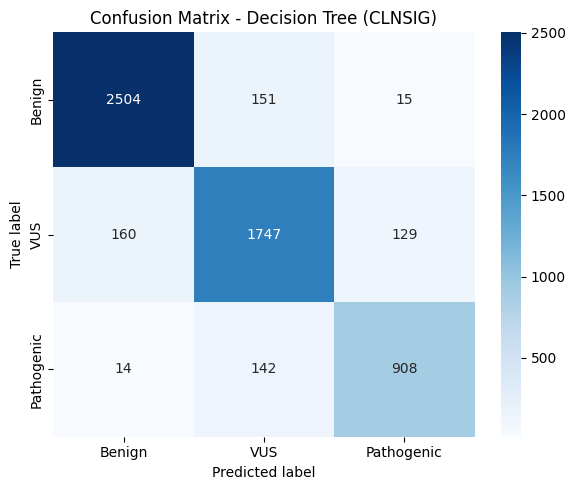

In [ ]:

# Model base
dt = DecisionTreeClassifier(random_state=42)
 
# Pipeline preprocessament + model
pipeline_dt = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", dt)
])
 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
# Cerca d'hiperparàmetres
param_grid = {
    "model__max_depth": [5, 10, 20, None],
    "model__min_samples_split": [2, 10, 20],
    "model__min_samples_leaf": [1, 5, 10],
    "model__class_weight": [None, "balanced"]
}
 
grid_dt = GridSearchCV(
    pipeline_dt,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    error_score="raise"
)
 
grid_dt.fit(X_train_val, y_train_val)

# Resultats de la validació creuada
print(f"Millors paràmetres: {grid_dt.best_params_}")
print(f"Millor CV F1 macro:  {grid_dt.best_score_:.4f}")
 
best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)
 
print("\nClassification report al test:")
print(classification_report(y_test, y_pred_dt, target_names=CLASS_NAMES))
print(f"\nTest F1 macro: {f1_score(y_test, y_pred_dt, average='macro'):.4f}")
print(f"Confusion matrix:\n{confusion_matrix(y_test, y_pred_dt)}")
 
plot_confusion_matrix(
    confusion_matrix(y_test, y_pred_dt),
    "Confusion Matrix - Decision Tree (CLNSIG)"
)

## Random Forest

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Millors paràmetres: {'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 0.3, 'model__max_depth': None, 'model__class_weight': None}
Millor CV F1 macro:  0.9043

Classification report al test:
              precision    recall  f1-score   support

      Benign       0.93      0.97      0.95      2670
         VUS       0.88      0.88      0.88      2036
  Pathogenic       0.92      0.84      0.88      1064

    accuracy                           0.91      5770
   macro avg       0.91      0.89      0.90      5770
weighted avg       0.91      0.91      0.91      5770


Test F1 macro: 0.9004
Confusion matrix:
[[2581   88    1]
 [ 173 1783   80]
 [   9  164  891]]


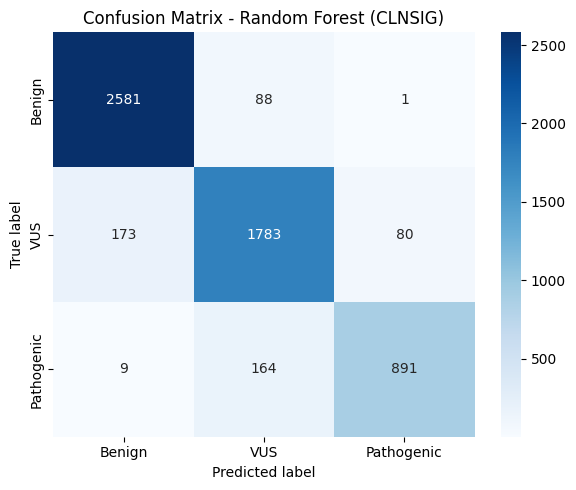

In [ ]:
# Model base
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Pipeline preprocessament + model
pipeline_rf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", rf)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cerca d'hiperparàmetres
param_dist = {
    "model__n_estimators":      [100, 200, 300],
    "model__max_depth":         [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf":  [1, 2, 5],
    "model__max_features":      ["sqrt", 0.3],
    "model__class_weight":      [None, "balanced"]
}

random_search_rf = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=param_dist,
    n_iter=15,
    scoring="f1_macro",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    refit=True
)

random_search_rf.fit(X_train_val, y_train_val)

# Resultats de la validació creuada
print(f"Millors paràmetres: {random_search_rf.best_params_}")
print(f"Millor CV F1 macro:  {random_search_rf.best_score_:.4f}")

best_rf = random_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print("\nClassification report al test:")
print(classification_report(y_test, y_pred_rf, target_names=CLASS_NAMES))
print(f"\nTest F1 macro: {f1_score(y_test, y_pred_rf, average='macro'):.4f}")
print(f"Confusion matrix:\n{confusion_matrix(y_test, y_pred_rf)}")

plot_confusion_matrix(
    confusion_matrix(y_test, y_pred_rf),
    "Confusion Matrix - Random Forest (CLNSIG)"
)

## MLP

/Users/eliag/Library/Python/3.9/lib/python/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 18 is smaller than n_iter=20. Running 18 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 18 candidates, totalling 90 fits
Millors paràmetres: {'model__learning_rate_init': 0.0005, 'model__hidden_layer_sizes': (64, 32), 'model__alpha': 0.001}
Millor CV F1 macro:  0.8700

Classification report al test:
              precision    recall  f1-score   support

      Benign       0.97      0.82      0.89      2670
         VUS       0.75      0.93      0.83      2036
  Pathogenic       0.90      0.84      0.87      1064

    accuracy                           0.86      5770
   macro avg       0.87      0.86      0.86      5770
weighted avg       0.88      0.86      0.86      5770


Test F1 macro: 0.8624
Confusion matrix:
[[2185  467   18]
 [  65 1894   77]
 [   3  169  892]]


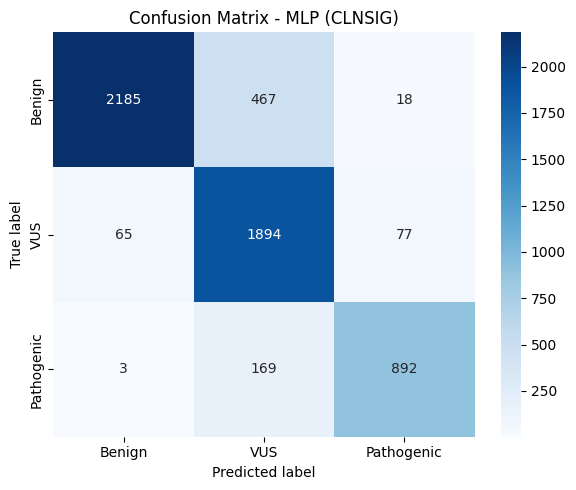

In [40]:
# Model base
mlp = MLPClassifier(
    activation="relu",
    solver="adam",
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    tol=1e-4,
    max_iter=500,
    random_state=42
)

# Pipeline preprocessament + model
pipeline_mlp = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", mlp)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cerca d'hiperparàmetres
param_dist = {
    "model__hidden_layer_sizes": [(64,), (128,), (64, 32)],
    "model__alpha":              [1e-3, 5e-3],
    "model__learning_rate_init": [1e-4, 5e-4, 1e-3],
}

random_search_mlp = RandomizedSearchCV(
    estimator=pipeline_mlp,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1_macro",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=1,
    refit=True,
    error_score="raise"
)

random_search_mlp.fit(X_train_val, y_train_val)

# Resultats de la validació creuada
print(f"Millors paràmetres: {random_search_mlp.best_params_}")
print(f"Millor CV F1 macro:  {random_search_mlp.best_score_:.4f}")

best_mlp = random_search_mlp.best_estimator_
y_pred_mlp = best_mlp.predict(X_test)

print("\nClassification report al test:")
print(classification_report(y_test, y_pred_mlp, target_names=CLASS_NAMES))
print(f"\nTest F1 macro: {f1_score(y_test, y_pred_mlp, average='macro'):.4f}")
print(f"Confusion matrix:\n{confusion_matrix(y_test, y_pred_mlp)}")

plot_confusion_matrix(
    confusion_matrix(y_test, y_pred_mlp),
    "Confusion Matrix - MLP (CLNSIG)"
)

## Interpretabilitat SHAP
Anàlisi d'interpretabilitat dels sis models entrenats mitjançant 
valors SHAP.

In [ ]:
CLASS_NAMES = ["Benign", "VUS", "Pathogenic"]


def normalize_sv_list(sv_raw):
    """Retorna llista de arrays 2D (n_samples, n_features) per classe."""
    if isinstance(sv_raw, list):
        return [np.array(sv, dtype=np.float64) for sv in sv_raw]
    sv_raw = np.array(sv_raw, dtype=np.float64)
    if sv_raw.ndim == 3:
        return [sv_raw[:, :, c] for c in range(sv_raw.shape[2])]
    return [sv_raw]


def plot_shap_multiclass(sv_list, feature_names, model_title,
                         class_names=CLASS_NAMES, top_k=15):
    clean = [f.replace("num__", "").replace("cat__", "") for f in feature_names]

    # Importància global: mitja de |SHAP| de totes les classes
    global_abs = np.mean([np.abs(sv).mean(axis=0) for sv in sv_list], axis=0)
    global_df = pd.DataFrame({"feature": clean, "importance": global_abs})
    top_global = global_df.nlargest(top_k, "importance").sort_values("importance")

    plt.figure(figsize=(10, 7))
    plt.barh(top_global["feature"], top_global["importance"], color="#4C72B0")
    plt.title(f"{model_title} – Importància global SHAP (Top {top_k})")
    plt.xlabel("Mean |SHAP value|")
    plt.tight_layout()
    plt.show()

    # SHAP signat per classe (mateixos top features)
    top_features = top_global["feature"].tolist()
    fig, axes = plt.subplots(1, len(class_names),
                             figsize=(6 * len(class_names), 7), sharey=True)
    if len(class_names) == 1:
        axes = [axes]
    for i, (sv, cn) in enumerate(zip(sv_list, class_names)):
        mean_signed = sv.mean(axis=0)
        sdf = pd.DataFrame({"feature": clean, "shap": mean_signed})
        sdf = (sdf[sdf["feature"].isin(top_features)]
               .drop_duplicates("feature")
               .set_index("feature")
               .reindex(top_features)
               .sort_values("shap"))
        colors = ["#C44E52" if x < 0 else "#4C72B0" for x in sdf["shap"]]
        axes[i].barh(sdf.index, sdf["shap"], color=colors)
        axes[i].axvline(0, color="black", linewidth=1)
        axes[i].set_title(f"Classe: {cn}")
        axes[i].set_xlabel("Mean SHAP value")
    fig.suptitle(f"{model_title} – SHAP signat per classe", fontsize=13)
    plt.tight_layout()
    plt.show()


def get_normalized_shap_multiclass(sv_list, feature_names):
    """Importància global normalitzada (suma = 1) per construir meta-df."""
    global_abs = np.mean([np.abs(sv).mean(axis=0) for sv in sv_list], axis=0)
    total = global_abs.sum() or 1
    clean = [f.replace("num__", "").replace("cat__", "") for f in feature_names]
    return pd.Series(global_abs / total, index=clean)


def plot_cross_model_shap(meta_df, model_cols, title_suffix):
    top15 = meta_df.sort_values("mean_rank").head(15)
    print(f"Top 15 features més consistents entre models ({title_suffix}):")
    display(top15[model_cols + ["mean_across_models", "mean_rank"]].round(4))

    plt.figure(figsize=(9, 8))
    sns.heatmap(top15[model_cols], annot=True, fmt=".3f",
                cmap="YlOrRd", linewidths=0.5)
    plt.title(f"Importància SHAP normalitzada – Top 15 ({title_suffix})")
    plt.tight_layout()
    plt.show()

    top15_r = meta_df.sort_values("mean_rank").head(15).copy()
    top15_r["feature"] = top15_r.index
    plt.figure(figsize=(10, 7))
    plt.barh(top15_r["feature"][::-1], top15_r["mean_rank"][::-1], color="#4C72B0")
    plt.title(f"Ranking mitjà entre models – {title_suffix}")
    plt.xlabel("Mean rank")
    plt.tight_layout()
    plt.show()

/Users/eliag/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Models lineals

Càlcul dels valors SHAP per als tres models lineals mitjançant 
`LinearExplainer`. Aquesta implementació és exacta i computacionalment 
molt eficient, ja que aprofita els coeficients apresos del model.

Classes: 3, forma: (5770, 3774)


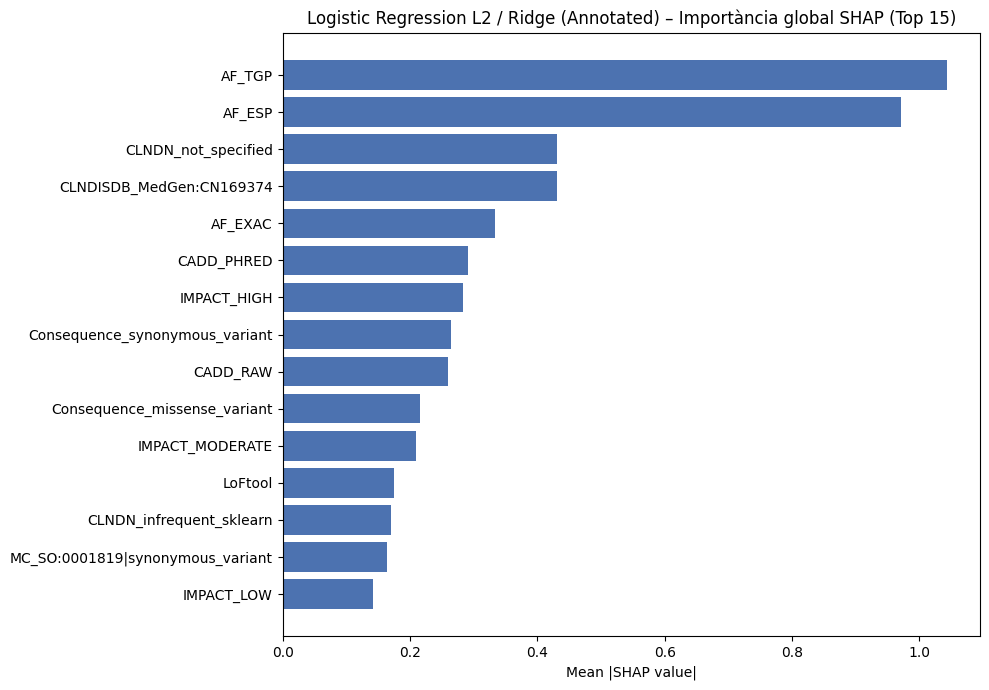

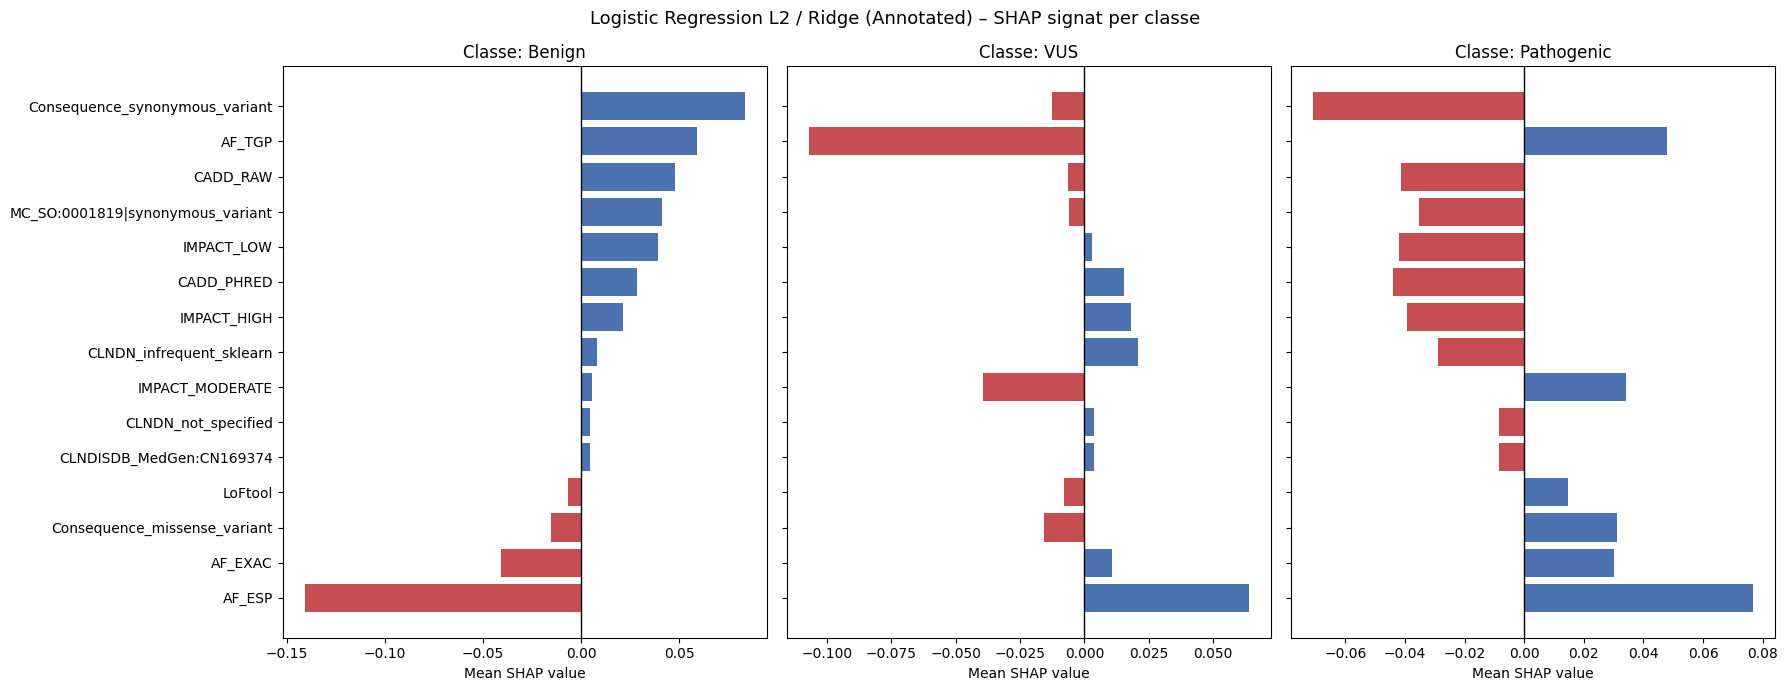

In [ ]:
# SHAP per Logistic Regression L2 (Ridge)
X_test_tr_lr_l2 = best_lr_l2.named_steps["preprocess"].transform(X_test)
if scipy.sparse.issparse(X_test_tr_lr_l2):
    X_test_tr_lr_l2 = X_test_tr_lr_l2.toarray().astype(np.float64)
else:
    X_test_tr_lr_l2 = np.array(X_test_tr_lr_l2, dtype=np.float64)

# Obtenir noms de features després del preprocessament
feature_names_lr_l2 = best_lr_l2.named_steps["preprocess"].get_feature_names_out()
explainer_lr_l2 = shap.LinearExplainer(best_lr_l2.named_steps["model"], X_test_tr_lr_l2)
shap_values_lr_l2_raw = explainer_lr_l2.shap_values(X_test_tr_lr_l2)
sv_list_lr_l2 = normalize_sv_list(shap_values_lr_l2_raw)

print(f"Classes: {len(sv_list_lr_l2)}, forma: {sv_list_lr_l2[0].shape}")
plot_shap_multiclass(sv_list_lr_l2, feature_names_lr_l2, "Logistic Regression L2 / Ridge (Annotated)")

Classes: 3, forma: (5770, 3774)


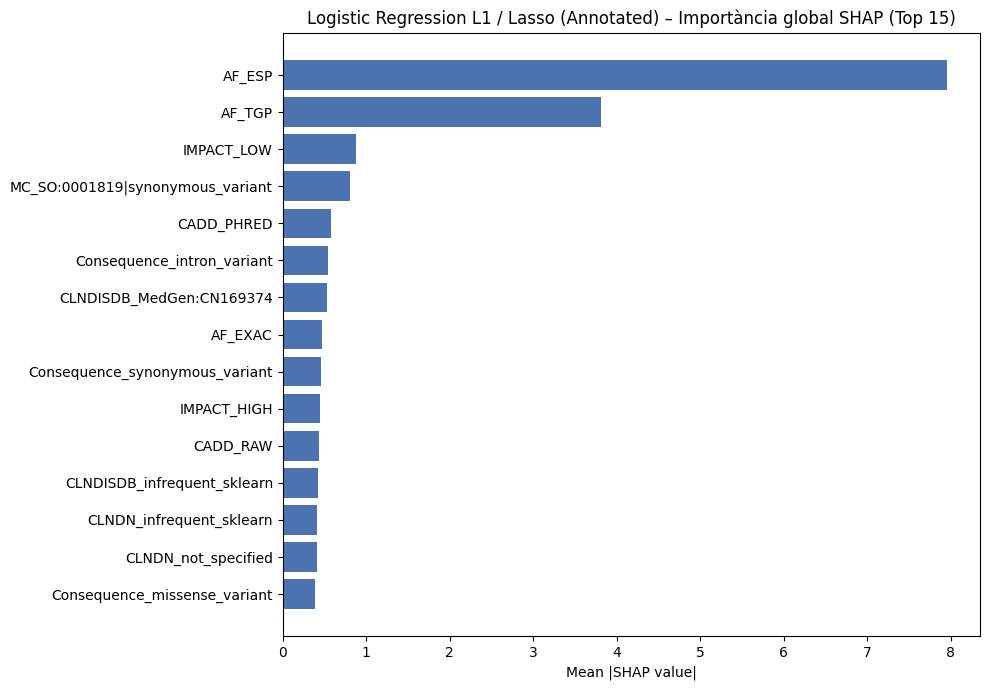

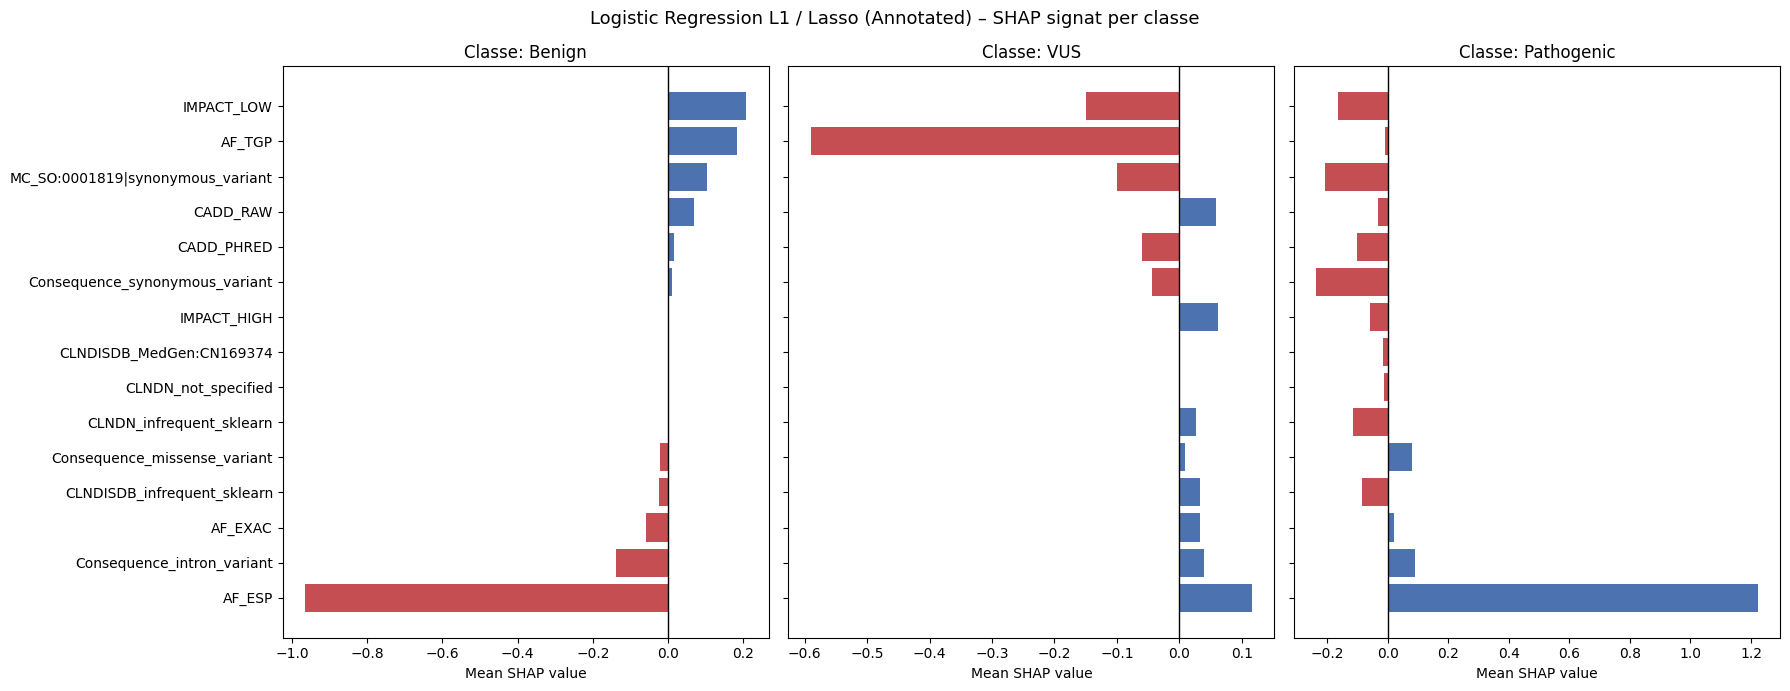

In [ ]:
# SHAP per Logistic Regression L1 (Lasso)
X_test_tr_lr_l1 = best_lr_l1.named_steps["preprocess"].transform(X_test)
if scipy.sparse.issparse(X_test_tr_lr_l1):
    X_test_tr_lr_l1 = X_test_tr_lr_l1.toarray().astype(np.float64)
else:
    X_test_tr_lr_l1 = np.array(X_test_tr_lr_l1, dtype=np.float64)

# Obtenir noms de features després del preprocessament
feature_names_lr_l1 = best_lr_l1.named_steps["preprocess"].get_feature_names_out()
explainer_lr_l1 = shap.LinearExplainer(best_lr_l1.named_steps["model"], X_test_tr_lr_l1)
shap_values_lr_l1_raw = explainer_lr_l1.shap_values(X_test_tr_lr_l1)
sv_list_lr_l1 = normalize_sv_list(shap_values_lr_l1_raw)

print(f"Classes: {len(sv_list_lr_l1)}, forma: {sv_list_lr_l1[0].shape}")
plot_shap_multiclass(sv_list_lr_l1, feature_names_lr_l1, "Logistic Regression L1 / Lasso (Annotated)")

Classes: 3, forma: (5770, 3774)


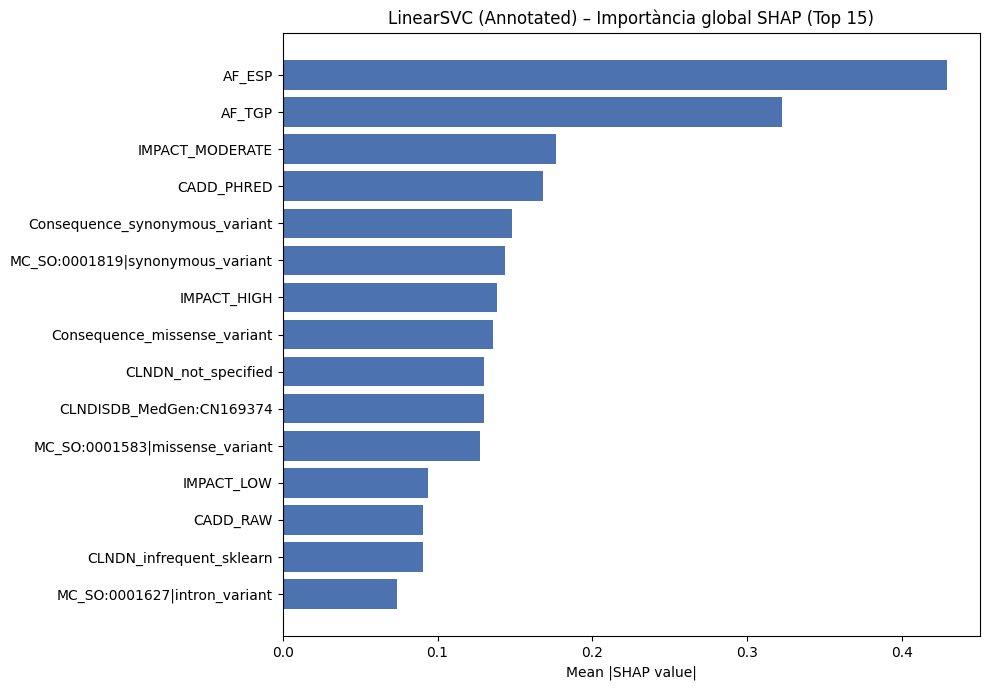

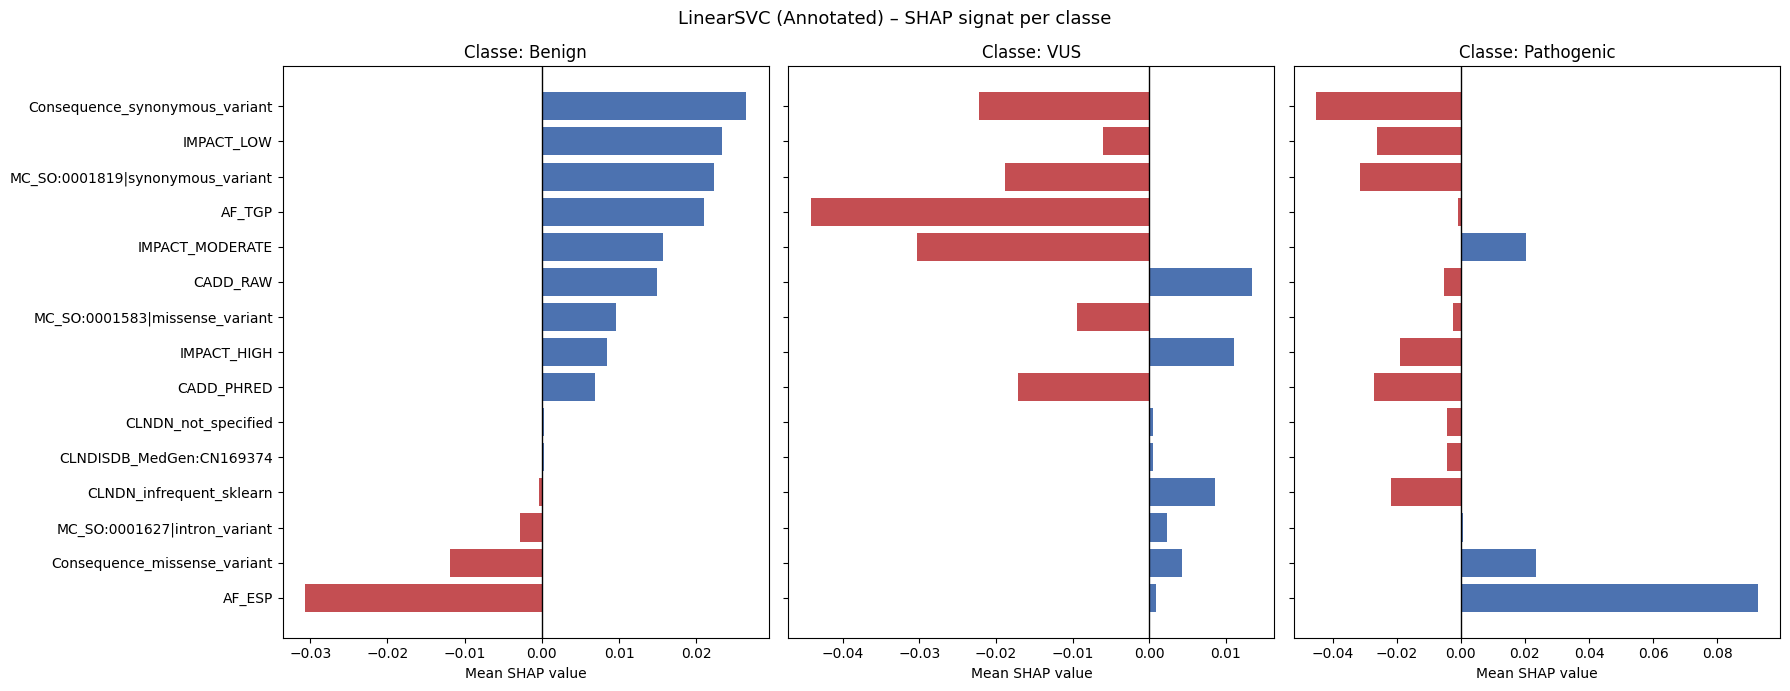

In [ ]:
# SHAP per LinearSVC
X_test_tr_svc = best_svc.named_steps["preprocess"].transform(X_test)
if scipy.sparse.issparse(X_test_tr_svc):
    X_test_tr_svc = X_test_tr_svc.toarray().astype(np.float64)
else:
    X_test_tr_svc = np.array(X_test_tr_svc, dtype=np.float64)

# Obtenir noms de features després del preprocessament
feature_names_svc = best_svc.named_steps["preprocess"].get_feature_names_out()
explainer_svc = shap.LinearExplainer(best_svc.named_steps["model"], X_test_tr_svc)
shap_values_svc_raw = explainer_svc.shap_values(X_test_tr_svc)
sv_list_svc = normalize_sv_list(shap_values_svc_raw)

print(f"Classes: {len(sv_list_svc)}, forma: {sv_list_svc[0].shape}")
plot_shap_multiclass(sv_list_svc, feature_names_svc, "LinearSVC (Annotated)")

### Decision Tree

Càlcul dels valors SHAP mitjançant `TreeExplainer`, que aprofita 
l'estructura de l'arbre per obtenir valors exactes de manera eficient.

Classes: 3, forma: (5770, 3774)


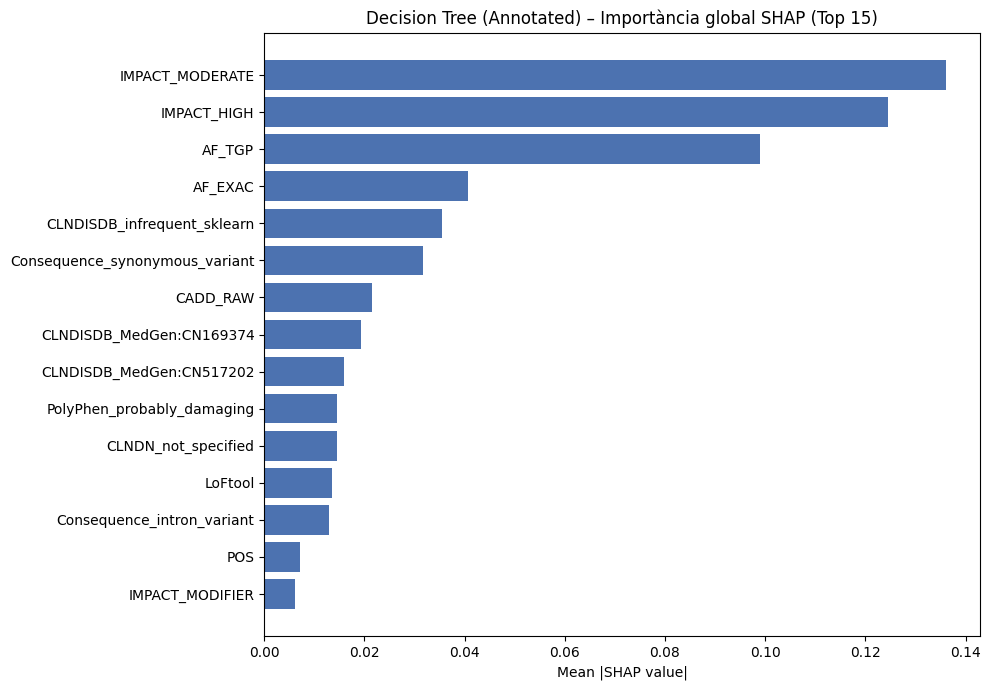

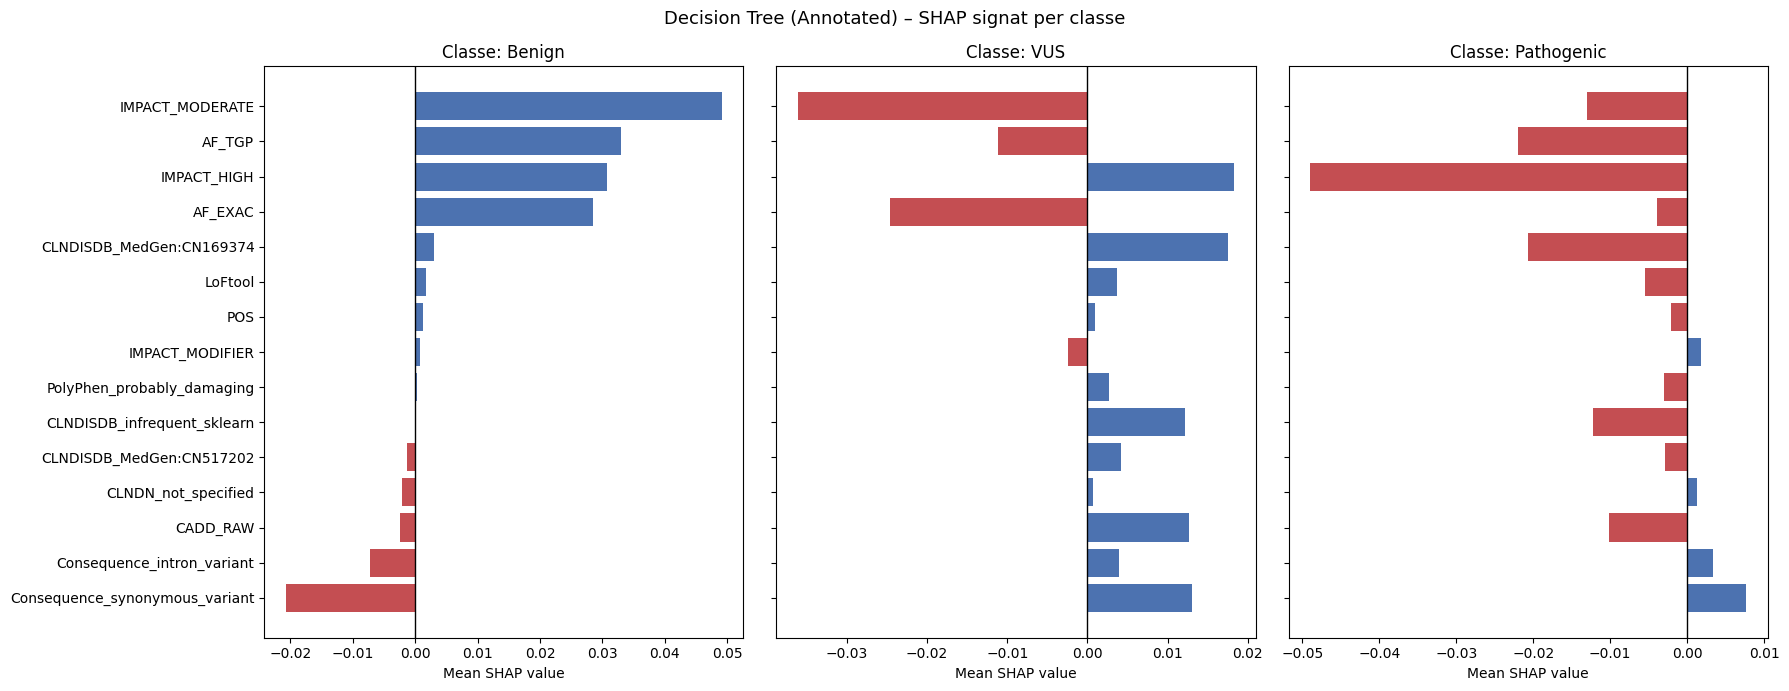

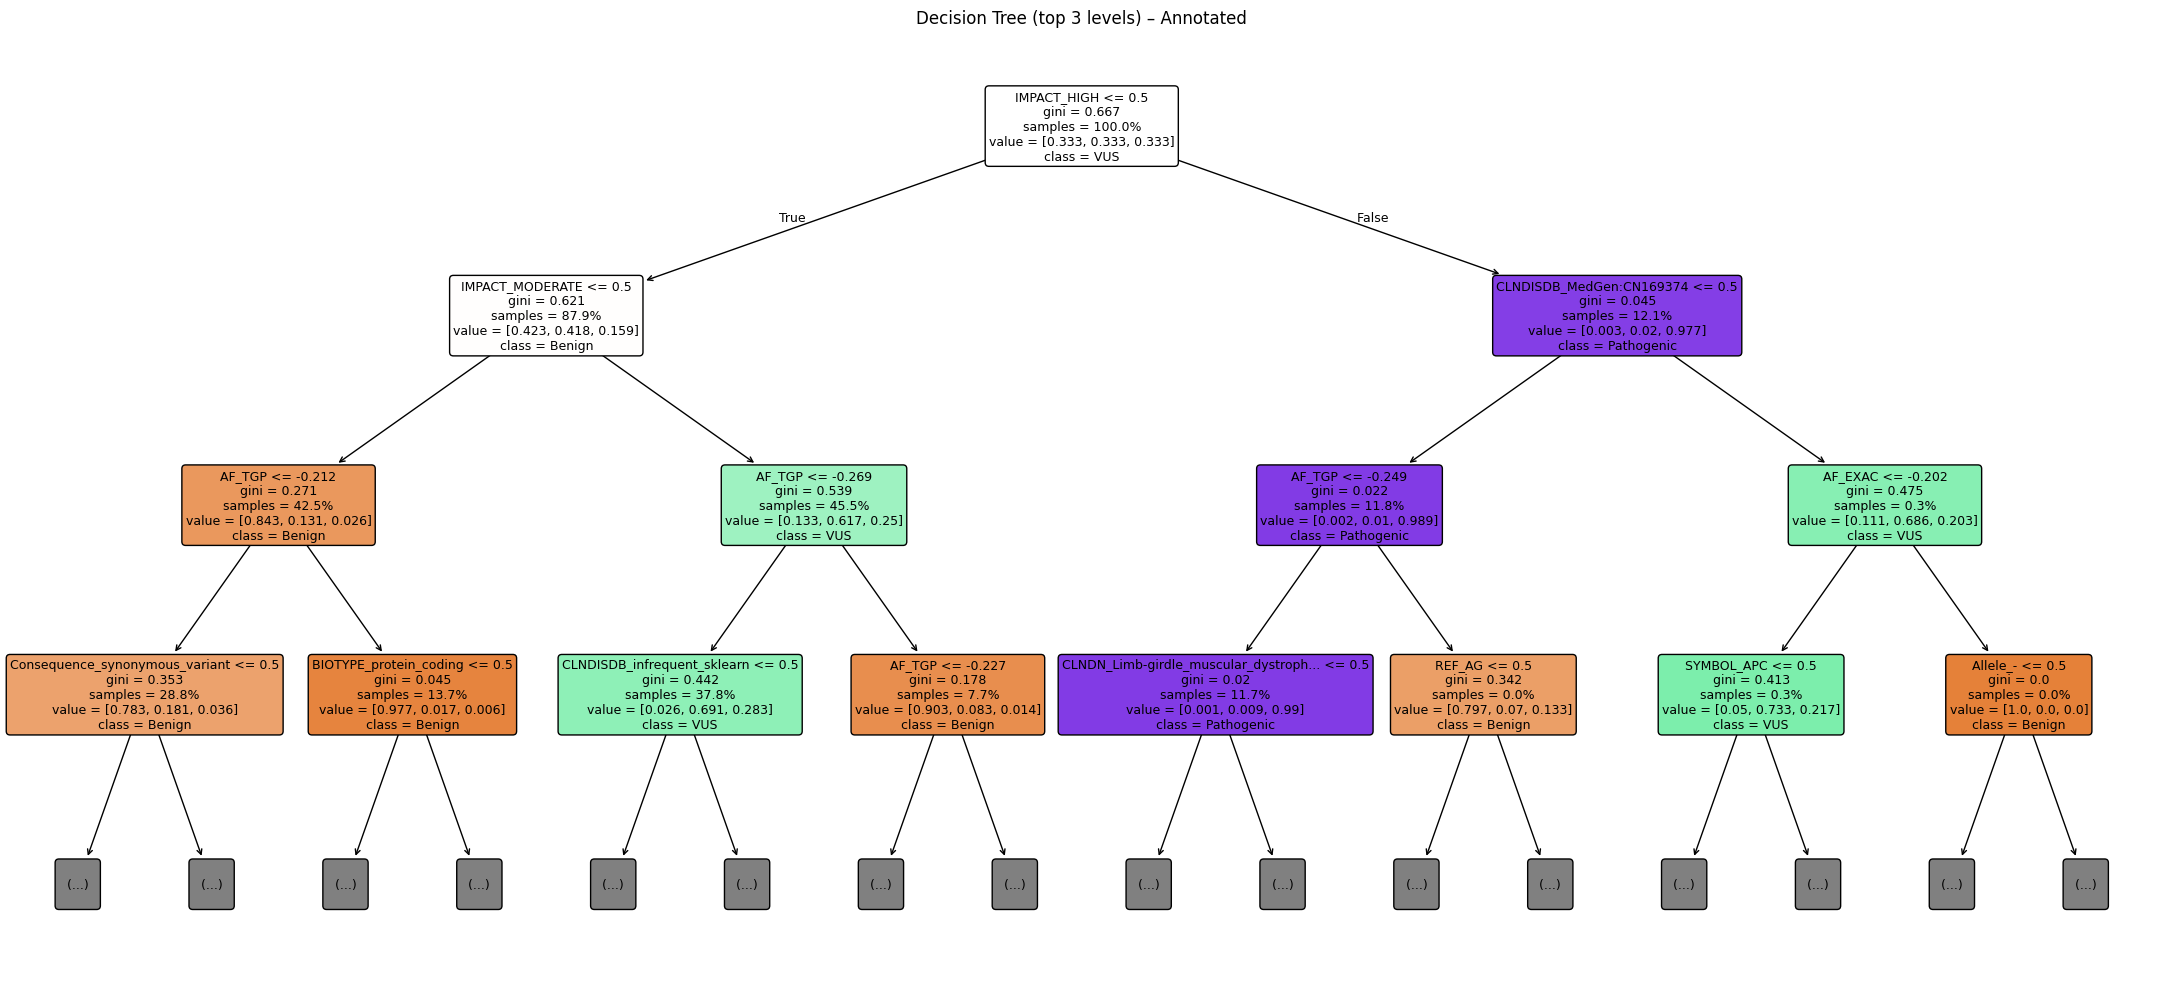

In [ ]:
# SHAP per Decision Tree
X_test_tr_dt = best_dt.named_steps["preprocess"].transform(X_test)
if scipy.sparse.issparse(X_test_tr_dt):
    X_test_tr_dt = X_test_tr_dt.toarray().astype(np.float64)
else:
    X_test_tr_dt = np.array(X_test_tr_dt, dtype=np.float64)

# Obtenir noms de features després del preprocessament
feature_names_dt = best_dt.named_steps["preprocess"].get_feature_names_out()
explainer_dt = shap.TreeExplainer(best_dt.named_steps["model"])
shap_values_dt_raw = explainer_dt.shap_values(X_test_tr_dt)
sv_list_dt = normalize_sv_list(shap_values_dt_raw)

print(f"Classes: {len(sv_list_dt)}, forma: {sv_list_dt[0].shape}")
plot_shap_multiclass(sv_list_dt, feature_names_dt, "Decision Tree (Annotated)")

def shorten(name, n=35):
    name = name.replace("num__", "").replace("cat__", "")
    return name[:n] + "..." if len(name) > n else name

plt.figure(figsize=(22, 10))
plot_tree(
    best_dt.named_steps["model"],
    feature_names=[shorten(f) for f in feature_names_dt],
    class_names=CLASS_NAMES,
    filled=True, rounded=True, max_depth=3,
    fontsize=9, impurity=True, proportion=True
)
plt.title("Decision Tree (top 3 levels) – Annotated")
plt.tight_layout()
plt.show()

### Random Forest

Càlcul dels valors SHAP mitjançant `TreeExplainer` amb aproximació 
per conjunts d'arbres. S'utilitza `approximate=True` per reduir 
el cost computacional mantenint una estimació fiable.

Classes: 3, forma: (5770, 3774)


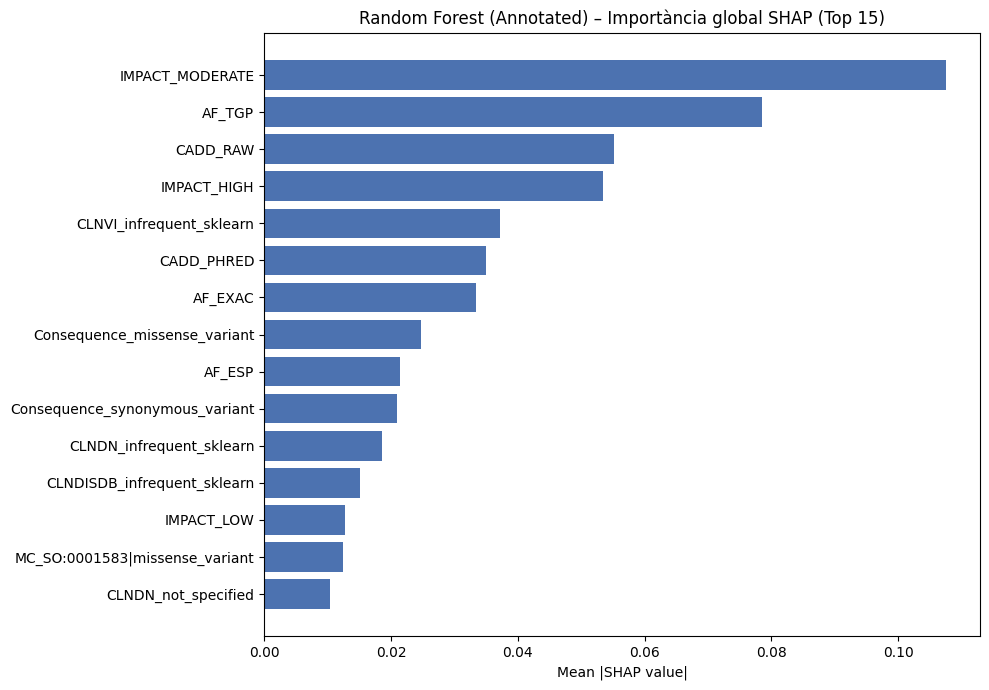

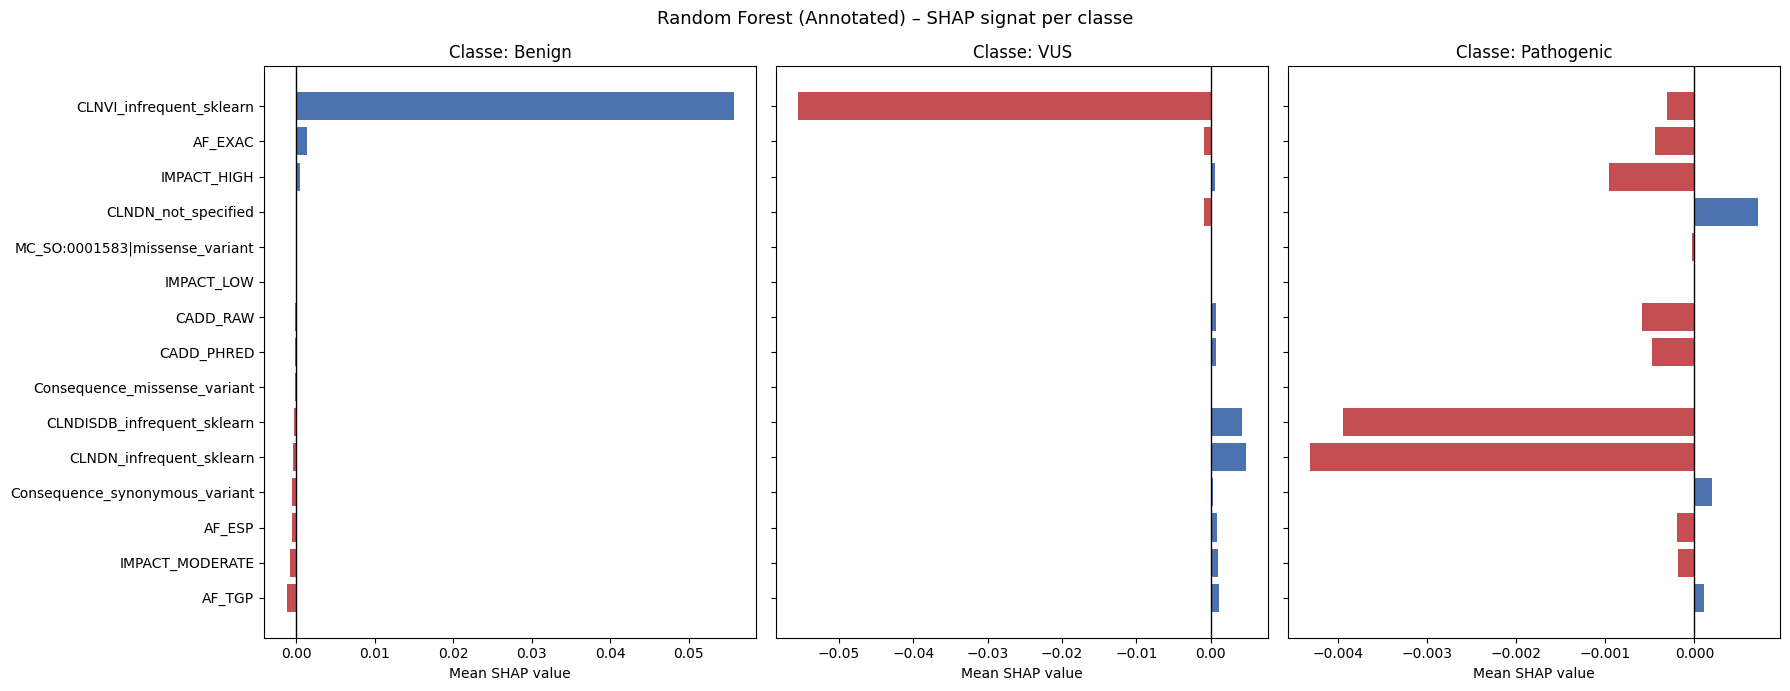

In [ ]:
# SHAP per Random Forest
X_test_tr_rf = best_rf.named_steps["preprocess"].transform(X_test)
if scipy.sparse.issparse(X_test_tr_rf):
    X_test_tr_rf = X_test_tr_rf.toarray().astype(np.float64)
else:
    X_test_tr_rf = np.array(X_test_tr_rf, dtype=np.float64)

# Obtenir noms de features després del preprocessament
feature_names_rf = best_rf.named_steps["preprocess"].get_feature_names_out()
explainer_rf = shap.TreeExplainer(best_rf.named_steps["model"])
shap_values_rf_raw = explainer_rf.shap_values(
    X_test_tr_rf, approximate=True, check_additivity=False
)
sv_list_rf = normalize_sv_list(shap_values_rf_raw)

print(f"Classes: {len(sv_list_rf)}, forma: {sv_list_rf[0].shape}")
plot_shap_multiclass(sv_list_rf, feature_names_rf, "Random Forest (Annotated)")

### MLP

Càlcul dels valors SHAP mitjançant `KernelExplainer`, l'únic 
mètode aplicable a xarxes neuronals. 

Background shape: (100, 3774)
Test sample shape: (200, 3774)


  0%|          | 0/200 [00:00<?, ?it/s]/Users/eliag/Library/Python/3.9/lib/python/site-packages/shap/explainers/_kernel.py:706: RuntimeWarning: divide by zero encountered in matmul
  w = np.linalg.solve(X.T @ WX, WX.T @ y)
/Users/eliag/Library/Python/3.9/lib/python/site-packages/shap/explainers/_kernel.py:706: RuntimeWarning: overflow encountered in matmul
  w = np.linalg.solve(X.T @ WX, WX.T @ y)
/Users/eliag/Library/Python/3.9/lib/python/site-packages/shap/explainers/_kernel.py:706: RuntimeWarning: invalid value encountered in matmul
  w = np.linalg.solve(X.T @ WX, WX.T @ y)
  0%|          | 1/200 [00:00<00:38,  5.11it/s]/Users/eliag/Library/Python/3.9/lib/python/site-packages/shap/explainers/_kernel.py:706: RuntimeWarning: divide by zero encountered in matmul
  w = np.linalg.solve(X.T @ WX, WX.T @ y)
/Users/eliag/Library/Python/3.9/lib/python/site-packages/shap/explainers/_kernel.py:706: RuntimeWarning: overflow encountered in matmul
  w = np.linalg.solve(X.T @ WX, WX.T @ y)
/Users/

Classes: 3, forma: (200, 3774)


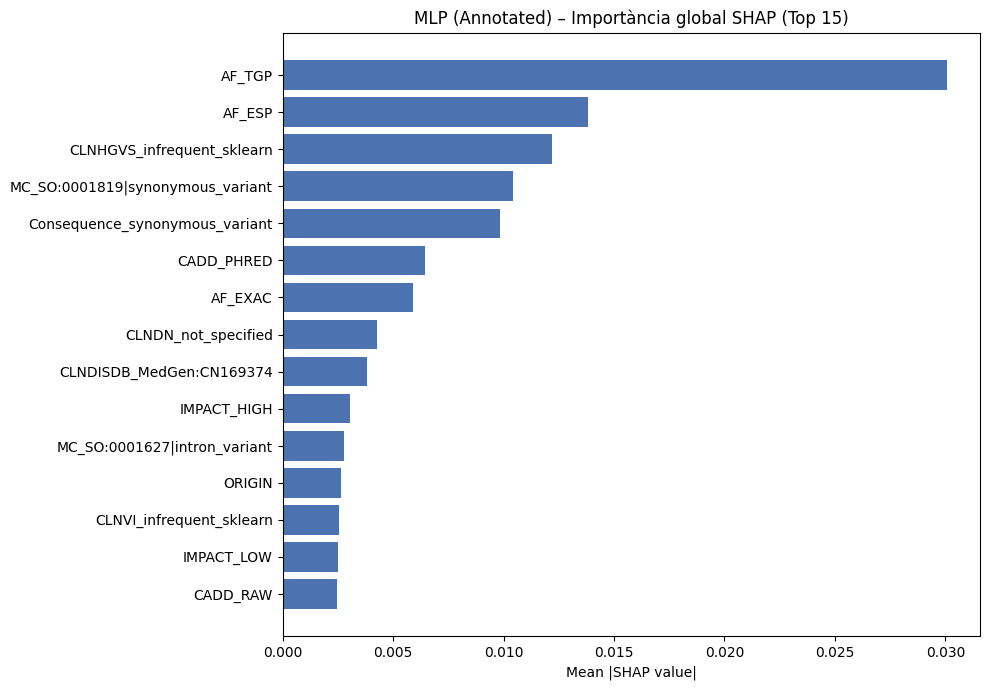

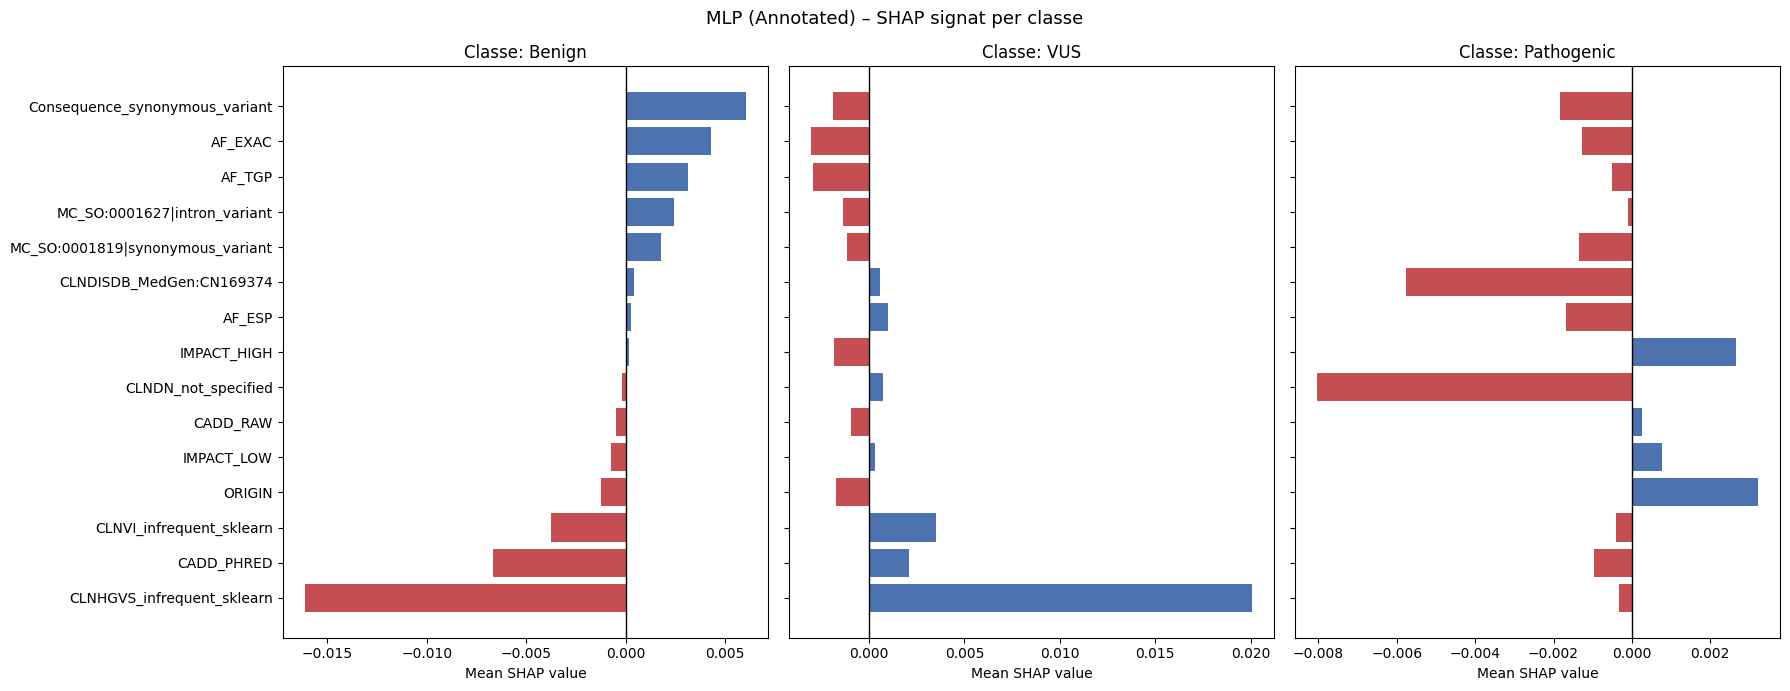

In [ ]:
# SHAP per MLP
X_test_tr_mlp = best_mlp.named_steps["preprocess"].transform(X_test)
if scipy.sparse.issparse(X_test_tr_mlp):
    X_test_tr_mlp = X_test_tr_mlp.toarray().astype(np.float64)
else:
    X_test_tr_mlp = np.array(X_test_tr_mlp, dtype=np.float64)

#  Obtenir noms de features després del preprocessament
X_train_tr_mlp = best_mlp.named_steps["preprocess"].transform(X_train_val)
if scipy.sparse.issparse(X_train_tr_mlp):
    X_train_tr_mlp = X_train_tr_mlp.toarray().astype(np.float64)
else:
    X_train_tr_mlp = np.array(X_train_tr_mlp, dtype=np.float64)

# Obtenir noms de features després del preprocessament
feature_names_mlp = best_mlp.named_steps["preprocess"].get_feature_names_out()
mlp_model = best_mlp.named_steps["model"]

# Mostreig aleatori en lloc de kmeans → evita centroides extrems
rng = np.random.RandomState(42)
bg_idx   = rng.choice(X_train_tr_mlp.shape[0], size=100, replace=False)
test_idx = rng.choice(X_test_tr_mlp.shape[0],  size=200, replace=False)

# SHAP és molt costós per MLP, així que fem un mostreig petit i nsamples limitat
background_mlp = X_train_tr_mlp[bg_idx]
X_test_sample  = X_test_tr_mlp[test_idx]

print("Background shape:", background_mlp.shape)
print("Test sample shape:", X_test_sample.shape)

# KernelExplainer per MLP (model predict_proba + background sample)
explainer_mlp = shap.KernelExplainer(mlp_model.predict_proba, background_mlp)
shap_values_mlp_raw = explainer_mlp.shap_values(X_test_sample, nsamples=200)
sv_list_mlp = normalize_sv_list(shap_values_mlp_raw)

print(f"Classes: {len(sv_list_mlp)}, forma: {sv_list_mlp[0].shape}")
plot_shap_multiclass(sv_list_mlp, feature_names_mlp, "MLP (Annotated)")

## Comparació Interpretabilitat entre models

Top 15 features més consistents entre models (Annotated):


,Decision Tree,Random Forest,MLP,Logistic L2,Logistic L1,Linear SVC,mean_across_models,mean_rank
AF_TGP,0.1450,0.1086,0.0735,0.1182,0.1203,0.0648,0.1051,1.8333
AF_ESP,0.0086,0.0297,0.0338,0.1101,0.2506,0.0863,0.0865,5.1667
IMPACT_HIGH,0.1824,0.0739,0.0074,0.0322,0.0141,0.0279,0.0563,6.6667
Consequence_synonymous_variant,0.0463,0.0289,0.0241,0.0299,0.0145,0.0298,0.0289,7.1667
CADD_PHRED,0.0075,0.0484,0.0157,0.0330,0.0184,0.0338,0.0261,7.3333
CLNDISDB_MedGen:CN169374,0.0283,0.0131,0.0094,0.0489,0.0166,0.0261,0.0237,8.6667
AF_EXAC,0.0594,0.0463,0.0145,0.0377,0.0148,0.0086,0.0302,9.0000
CADD_RAW,0.0314,0.0765,0.0060,0.0295,0.0137,0.0182,0.0292,9.6667
IMPACT_MODERATE,0.1992,0.1488,0.0038,0.0237,0.0075,0.0355,0.0698,10.0000
CLNDN_not_specified,0.0213,0.0144,0.0105,0.0489,0.0128,0.0261,0.0223,10.0000


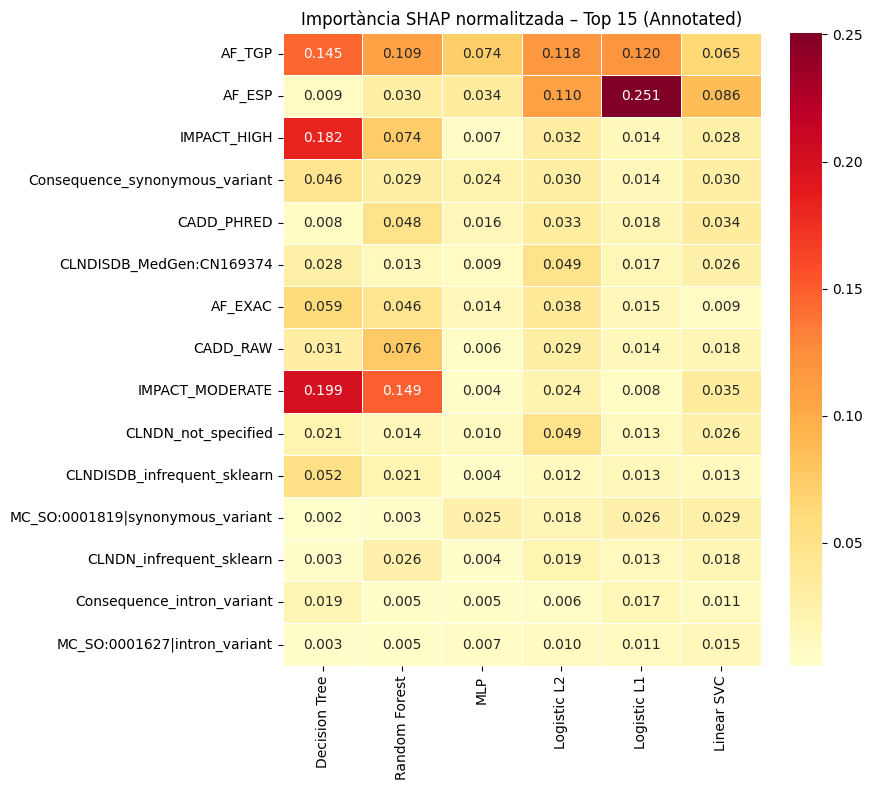

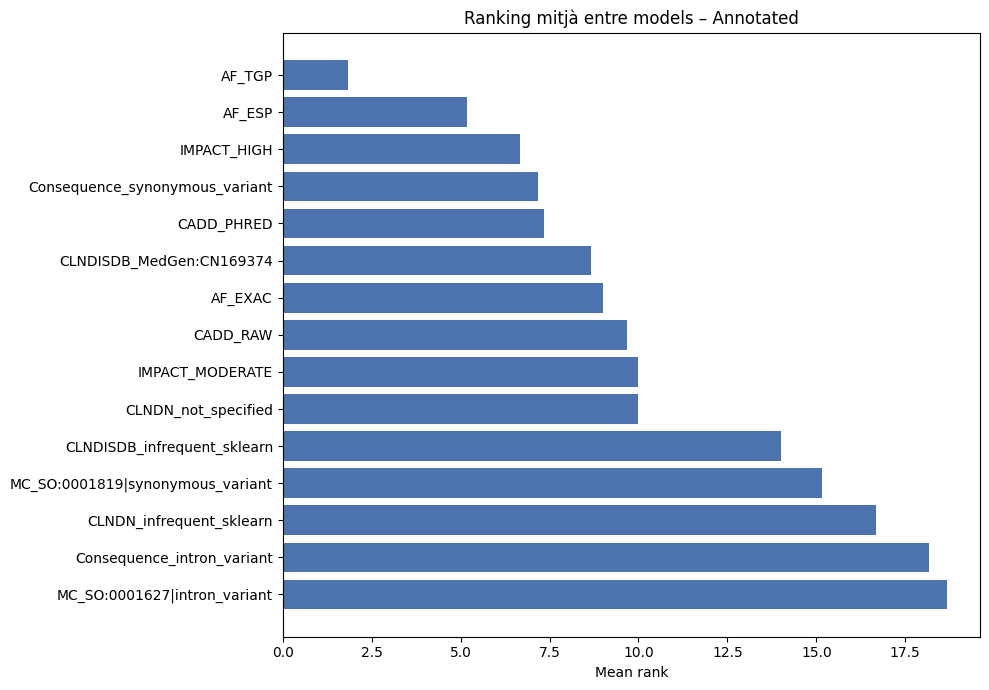

In [ ]:
# Construcció del meta DataFrame amb importància SHAP normalitzada per cada model
importance_dt_ann       = get_normalized_shap_multiclass(sv_list_dt,    feature_names_dt)
importance_rf_ann       = get_normalized_shap_multiclass(sv_list_rf,    feature_names_rf)
importance_mlp_ann      = get_normalized_shap_multiclass(sv_list_mlp,   feature_names_mlp)
importance_lr_l2_ann    = get_normalized_shap_multiclass(sv_list_lr_l2, feature_names_lr_l2)
importance_lr_l1_ann    = get_normalized_shap_multiclass(sv_list_lr_l1, feature_names_lr_l1)
importance_svc_ann      = get_normalized_shap_multiclass(sv_list_svc,   feature_names_svc)

# Crear DataFrame amb importància SHAP normalitzada per cada model
meta_ann = pd.DataFrame({
    "Decision Tree":  importance_dt_ann,
    "Random Forest":  importance_rf_ann,
    "MLP":            importance_mlp_ann,
    "Logistic L2":    importance_lr_l2_ann,
    "Logistic L1":    importance_lr_l1_ann,
    "Linear SVC":     importance_svc_ann,
}).fillna(0)

# Calcular mitjana i ranking entre models
model_cols = ["Decision Tree", "Random Forest", "MLP", "Logistic L2", "Logistic L1", "Linear SVC"]
meta_ann["mean_across_models"] = meta_ann[model_cols].mean(axis=1)
for col in model_cols:
    meta_ann[f"rank_{col}"] = meta_ann[col].rank(ascending=False).astype(int)
meta_ann["mean_rank"] = meta_ann[[f"rank_{col}" for col in model_cols]].mean(axis=1)

plot_cross_model_shap(meta_ann, model_cols, "Annotated")

## Exportar resultats per a la comparació

In [21]:
import pickle
import os

results_annotated = {
    'dt_cv':    grid_dt.best_score_,
    'rf_cv':    random_search_rf.best_score_,
    'mlp_cv':   random_search_mlp.best_score_,
    'l2_cv':    grid_lr_l2.best_score_,
    'l1_cv':    grid_lr_l1.best_score_,
    'svc_cv':   grid_svc.best_score_,
    'y_test':       y_test,
    'y_pred_dt':    y_pred_dt,
    'y_pred_rf':    y_pred_rf,
    'y_pred_mlp':   y_pred_mlp,
    'y_pred_lr_l2': y_pred_lr_l2,
    'y_pred_lr_l1': y_pred_lr_l1,
    'y_pred_svc':   y_pred_svc,
    'CLASS_NAMES':  CLASS_NAMES,
}

out_path = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'results_clnsig_annotated.pkl')
with open(out_path, 'wb') as f:
    pickle.dump(results_annotated, f)

print(f'Resultats guardats a {out_path}')

Resultats guardats a /Users/eliag/Documents/TFG/tfg-genetic-variants/notebooks/results_clnsig_annotated.pkl
